# Power Analysis and Sample Size Calculation

## Overview

Statistical power is the probability of detecting a true effect when it exists: Power = 1 − β (where β = Type II error rate). A study with insufficient power wastes resources and may produce a false negative — concluding there is no effect when one exists.

**The four quantities that determine power:**

| Quantity | Symbol | Typical value | Relationship |
|---|---|---|---|
| Significance level | α | 0.05 | Lower α → lower power |
| Power | 1−β | 0.80 | Higher power → larger n |
| Effect size | d, f, w | Context-specific | Smaller effect → larger n |
| Sample size | n | To calculate | — |

Fix any three; solve for the fourth. In practice: specify α, 1−β, and the **minimum detectable effect (MDE)** → compute required n.

**Effect size conventions (Cohen):**

| Test | Small | Medium | Large |
|---|---|---|---|
| t-test (Cohen's d) | 0.2 | 0.5 | 0.8 |
| ANOVA (Cohen's f) | 0.1 | 0.25 | 0.4 |
| Proportion (Cohen's h) | 0.2 | 0.5 | 0.8 |
| Correlation (Cohen's q) | 0.1 | 0.3 | 0.5 |

Cohen's conventions are a last resort — use domain knowledge or pilot data to specify a practically meaningful effect size.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(pwr)           # pwr.t.test(), pwr.2p.test(), pwr.anova.test()
library(patchwork)

# ── Common power analysis scenarios ──────────────────────────────────────────
# Scenario: testing whether a restoration intervention improves species richness
# Pilot data suggests: control mean=18, SD=5; MDE = 3 species (16.7% increase)
# α = 0.05, power = 0.80

control_mean <- 18
control_sd   <- 5
mde          <- 3          # minimum detectable effect (units: species)
cohen_d      <- mde / control_sd  # standardised effect size
cat(sprintf("Cohen's d = %.2f / %.2f = %.3f\n", mde, control_sd, cohen_d))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'pwr' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version 4.4.

Cohen's d = 3.00 / 5.00 = 0.600


---

## Two-Sample t-Test Power

Required n per group: 45 (total: 90)


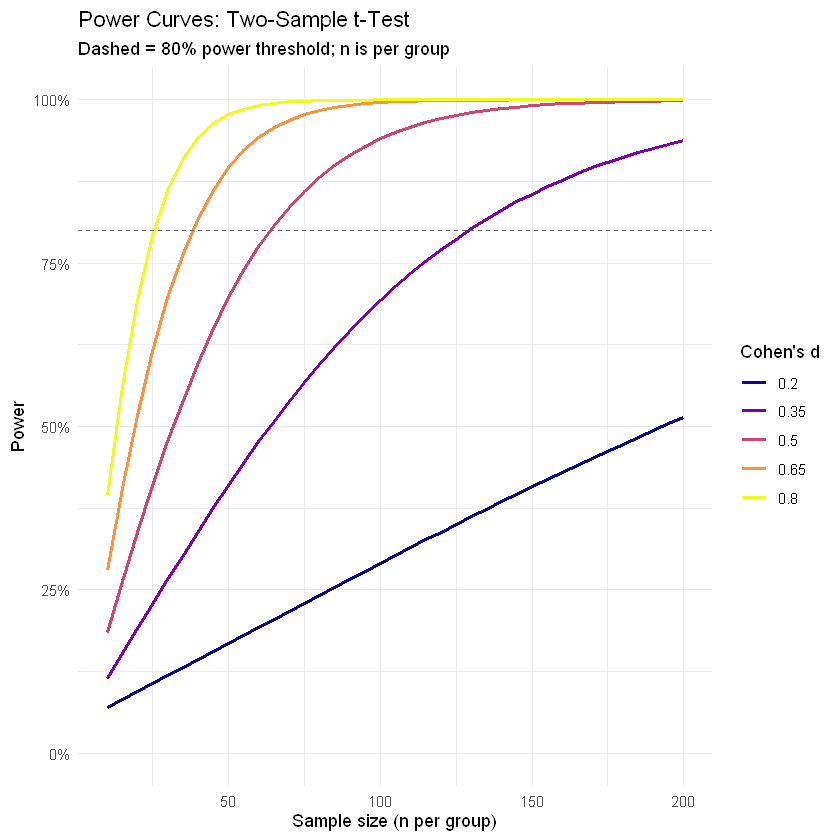

In [2]:
# pwr.t.test: two-sample, equal group sizes
t_power <- pwr::pwr.t.test(
  d    = cohen_d,
  sig.level = 0.05,
  power     = 0.80,
  type      = "two.sample",
  alternative = "two.sided"
)
cat(sprintf("Required n per group: %d (total: %d)\n",
            ceiling(t_power$n), ceiling(t_power$n)*2))

# ── Power curve: n vs. power for varying effect sizes ────────────────────────
power_curves <- expand_grid(
  n    = seq(10, 200, by=5),
  d    = c(0.2, 0.35, 0.5, 0.65, 0.8)
) %>%
  mutate(
    power = map2_dbl(n, d, ~pwr::pwr.t.test(
      n=.x, d=.y, sig.level=0.05,
      type="two.sample", alternative="two.sided"
    )$power)
  )

ggplot(power_curves, aes(x=n, y=power, color=factor(d), group=factor(d))) +
  geom_line(linewidth=1) +
  geom_hline(yintercept=0.80, linetype="dashed", color="gray40") +
  scale_color_viridis_d(name="Cohen's d", option="plasma") +
  scale_y_continuous(labels=scales::percent, limits=c(0,1)) +
  labs(title="Power Curves: Two-Sample t-Test",
       subtitle="Dashed = 80% power threshold; n is per group",
       x="Sample size (n per group)", y="Power") +
  theme_minimal()

---

## Power for Other Common Tests

In [3]:
# ── Proportion test (Cohen's h) ───────────────────────────────────────────────
# Control conversion: 15%; MDE: detect 20% (absolute +5pp)
p1 <- 0.15; p2 <- 0.20
h  <- pwr::ES.h(p2, p1)   # Cohen's h effect size for proportions
prop_power <- pwr::pwr.2p.test(
  h=h, sig.level=0.05, power=0.80, alternative="two.sided"
)
cat(sprintf("Proportions (%.0f%% vs %.0f%%): h=%.3f → n=%d per group\n",
            p1*100, p2*100, h, ceiling(prop_power$n)))

# ── One-way ANOVA (Cohen's f) ─────────────────────────────────────────────────
# 3 site types; expected between-group SD=3, within-group SD=5
f_effect <- 3/5   # Cohen's f = sigma_means / sigma_within
anova_power <- pwr::pwr.anova.test(
  k=3, f=f_effect, sig.level=0.05, power=0.80
)
cat(sprintf("One-way ANOVA (k=3): f=%.3f → n=%d per group\n",
            f_effect, ceiling(anova_power$n)))

# ── Chi-squared test (Cohen's w) ─────────────────────────────────────────────
# Observed vs. expected distribution across 4 habitat categories
chisq_power <- pwr::pwr.chisq.test(
  w=0.3, df=3, sig.level=0.05, power=0.80
)
cat(sprintf("Chi-squared (df=3): w=0.3 → n=%d total\n",
            ceiling(chisq_power$N)))

# ── Correlation (Cohen's q) ───────────────────────────────────────────────────
corr_power <- pwr::pwr.r.test(
  r=0.3, sig.level=0.05, power=0.80, alternative="two.sided"
)
cat(sprintf("Correlation (r=0.3): n=%d\n", ceiling(corr_power$n)))

Proportions (15% vs 20%): h=0.132 → n=903 per group
One-way ANOVA (k=3): f=0.600 → n=10 per group
Chi-squared (df=3): w=0.3 → n=122 total
Correlation (r=0.3): n=85


---

## Sensitivity Analysis: What Power Do We Have?

In [4]:
# Retrospective / sensitivity: given a fixed n, what effects can we detect?
# Useful when n is constrained by budget or available sites

fixed_n <- 40  # sites per group; budget constraint

detectable <- tibble(
  power_target = c(0.70, 0.80, 0.90)
) %>%
  mutate(
    min_d = map_dbl(power_target, ~pwr::pwr.t.test(
      n=fixed_n, sig.level=0.05, power=.x,
      type="two.sample", alternative="two.sided"
    )$d),
    min_effect_species = min_d * control_sd
  )

cat(sprintf("With n=%d per group (α=0.05):\n", fixed_n))
print(detectable %>% mutate(across(where(is.numeric), ~round(.x, 3))))
cat("\n→ Ask: is this minimum detectable effect scientifically meaningful?\n")
cat("  If not: collect more data, or accept the study is underpowered.\n")

With n=40 per group (α=0.05):
# A tibble: 3 × 3
  power_target min_d min_effect_species
         <dbl> <dbl>              <dbl>
1          0.7 0.562               2.81
2          0.8 0.634               3.17
3          0.9 0.734               3.67

→ Ask: is this minimum detectable effect scientifically meaningful?
  If not: collect more data, or accept the study is underpowered.


---

## Common Pitfalls

**1. Using Cohen's conventional effect sizes instead of domain-specific MDEs**  
Cohen's small/medium/large benchmarks were derived from social psychology literature and have no relevance to ecology, medicine, or industry conversion rates. A "medium" effect in one field may be enormous or trivial in another. Always ground the MDE in what would be scientifically or practically meaningful — see `minimum_detectable_effect.ipynb`.

**2. Conducting post-hoc power analysis after a non-significant result**  
Post-hoc power computed from the observed effect size is mathematically equivalent to a function of the p-value and adds no information. A non-significant result with "low post-hoc power" does not mean the study was underpowered — it means the observed effect was small. Report the confidence interval for the effect size instead.

**3. Not accounting for attrition, clustering, or multiple outcomes**  
Standard power formulas assume complete data, independent observations, and a single primary outcome. Add 10–20% to account for dropout; multiply n by the design effect (DEFF = 1 + (m−1)×ICC) for clustered designs; apply a correction for multiple primary outcomes. Ignoring these systematically underestimates required n.

**4. Calculating power for a one-tailed test when the analysis will be two-tailed**  
One-tailed tests require smaller n and are tempting to justify post hoc. Unless the direction of the effect is specified in advance and a result in the opposite direction would be completely uninterpretable, use two-tailed power calculations and report two-tailed tests.

**5. Treating the power calculation as a one-time exercise**  
Power calculations should be revisited if the SD estimate changes after piloting, if the expected effect size is revised based on new information, or if the analysis plan changes (e.g. switching from t-test to ANCOVA). Document the assumptions and revisit them before data collection begins.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*